# **Sequence Perplexity**

## 📦 **Importing Packages**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/PepProtGraphAnalyzer')
from PepProtGraphAnalyzer.module.notebook import NotebookApp
from PepProtGraphAnalyzer.util.plotting import boxplot

app = NotebookApp('.env.jupyter.StarPep')
paths = app.paths()

[2025-09-23 19:44:16,256] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/out_paper/Starpep/Log/Sequences with Non-Natural Amino Acids.csv
[2025-09-23 19:44:23,557] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/StarPep/StarPep.csv
pdb_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/StarPep/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/out_paper/Starpep
sequence_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/StarPep/2025-04-07T19.42.20-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/StarPep/2025-04-07T19.56.31-Graph_Analyzer
min_seq_len: 10
max_seq_len: 100


## 📊 **Data Analysis**

### **Sequence Perplexity Data**

In [2]:
data = pd.read_csv(app.sequence_analysis['sequence_perplexity'])
data.head()

,sequence,esm2_perplexity,length
0,GIGAVLKVLTTGLPALISWIKRKRQQ,1.248190,26
1,GIGKFLHSAKKFGKAFVGEIMNS,1.358675,23
2,ILPWKWPWWPWRR,1.630518,13
3,KWCFRVCYRGICYRRCR,1.239974,17
4,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,1.467580,37


In [3]:
mean_perplexity = data['esm2_perplexity'].mean()
std_perplexity = data['esm2_perplexity'].std()

print(f"Perplejidad promedio: {mean_perplexity}")
print(f"Desviación estándar: {std_perplexity}")

Perplejidad promedio: 1.528928519046916
Desviación estándar: 0.248421440237545


### **Analysis of Perplexity of Sequences by Sequence Length Interval**

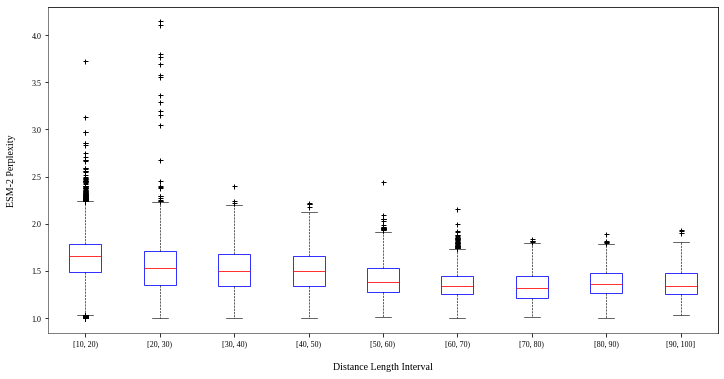

In [4]:
length_max = data['length'].max()
bin_size = 10
bins = np.arange(0, length_max + bin_size, bin_size)
bins[-1] = length_max + 1  # Ensure the last bin includes the max value

data['bin'] = pd.cut(data['length'], bins=bins, right=False)
data['bin'] = data['bin'].cat.rename_categories(lambda x: '[90, 100]' if str(x) == '[90, 101)' else str(x))

x_axis = 'bin'
y_axis = 'esm2_perplexity'
x_label = 'Distance Length Interval'
y_label = 'ESM-2 Perplexity'
output = paths['sequence_perplexity_path'].joinpath("ESM-2 Perplexity StarPep (boxplot)")

plt = boxplot(data, x_axis, y_axis, x_label, y_label, output=output, fig_size=(12, 6))
plt.show()

In [5]:
# Filter sequences
seq_to_filter = ['MWHLKLFAVLMICLLLLAQVDGSPIPQQSSAKRRPRRMTPFWRAVSLRPIGASCRDDSECITRLCRKRRCSLSVAQE', 
                 'RRLRPRRPRLPRPRPRPRPRPRSLPLPRPKPRPIPRPLPLPRPRPKPIPRPLPLPRPRPRRIPRPLPLPRPRPRPIPRPLPLPQPQPSPIPRPL']
result = data[data['sequence'].isin(seq_to_filter)]
result

,sequence,esm2_perplexity,length,bin
1938,RRLRPRRPRLPRPRPRPRPRPRSLPLPRPKPRPIPRPLPLPRPRPK...,1.317876,94,"[90, 100]"
10477,MWHLKLFAVLMICLLLLAQVDGSPIPQQSSAKRRPRRMTPFWRAVS...,1.161721,77,"[70, 80)"
